<a id="top"></a>
# Chapter 6 — Weyl semimetals and the axion angle

**PythTB — Tight-Binding Physics from Theory to Code** · Part II — Topological matter · chapter 6 of 8

[◀ 5 Higher-order topology and the Kitaev chain](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [Contents of the book](README.md) · [7 Stretching PythTB: butterfly, disorder, quasicrystal, the wall ▶](PythTB_07_Stretching_PythTB.ipynb)

**In this chapter**

- [§19 Weyl semimetals — monopoles, sliced Chern numbers, and Fermi arcs](#sec-19)
- [§20 The Fu–Kane–Mele model and the axion angle $\theta$](#sec-20)
- [Exercises for Part II](#exercises-II)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 52}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 6")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 6


<a id="sec-19"></a>

## 19. Weyl semimetals — monopoles, sliced Chern numbers, and Fermi arcs

A **Weyl node** is a point where two bands touch with the local form
$H \approx \sum_{ij} v_{ij} \delta k_i \sigma_j$: a monopole of Berry curvature with quantized
charge (chirality) $\chi = \pm1$. Nodes come in pairs (Nielsen–Ninomiya), and between a pair the
system is effectively a stack of 2D Chern insulators: the **Chern number of the 2D slice at fixed
$k_z$ jumps by $\chi$ when the slice crosses a node**. Bulk-boundary correspondence then forces
surface states — **Fermi arcs** — connecting the projections of the nodes.

Minimal model (single site, cubic lattice, spinful so the two bands are a $2\times2$ spin space):
$$
H(\mathbf K) = \sin K_x\,\sigma_x + \sin K_y\,\sigma_y +
\bigl[\cos K_z - \cos K_0 + 2 - \cos K_x - \cos K_y \bigr]\sigma_z,
$$
with Weyl nodes at $\mathbf K = (0, 0, \pm K_0)$. Every term is a one-line `set_hop` with a
$2\times2$ matrix. For the sliced Chern numbers we use a genuinely PythTB-2.0 move: build a *2D*
model whose hoppings are **functions of a parameter** `kz` — the third momentum demoted to a knob —
and sweep `chern_number` over it.

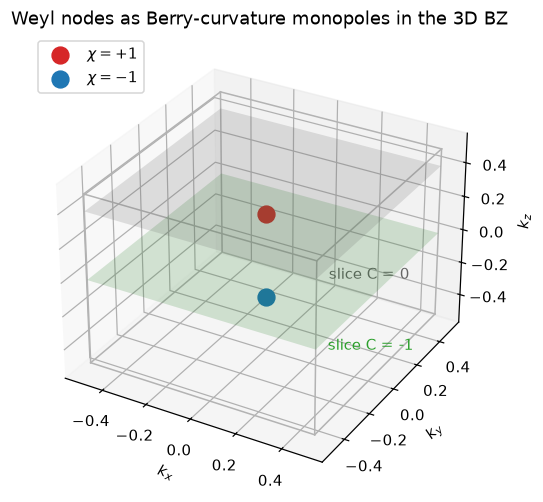

In [2]:
# the geography of a Weyl semimetal: 3D BZ, two nodes on the kz axis, and the
# 2D slices whose Chern numbers we are about to compute
fig = plt.figure(figsize=(6.2, 5.4))
ax = fig.add_subplot(projection="3d")
r = [-0.5, 0.5]
for zdir in (0, 1, 2):                                  # BZ cube edges
    for a in r:
        for b in r:
            seg = np.array([[a, b, -0.5], [a, b, 0.5]])
            seg = np.roll(seg, zdir, axis=1)
            ax.plot(*seg.T, color="0.7", lw=1)
ax.scatter([0], [0], [0.25], s=120, c="C3", marker="o", label=r"$\chi=+1$")
ax.scatter([0], [0], [-0.25], s=120, c="C0", marker="o", label=r"$\chi=-1$")
for kz_s, col in ((0.0, "C2"), (0.4, "0.5")):           # two example slices
    xx, yy = np.meshgrid(r, r)
    ax.plot_surface(xx, yy, np.full_like(xx, kz_s), alpha=0.18, color=col)
ax.text(0.55, -0.5, 0.02, "slice C = -1", color="C2")
ax.text(0.55, -0.5, 0.42, "slice C = 0", color="0.4")
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$"); ax.set_zlabel(r"$k_z$")
ax.legend(loc="upper left")
ax.set_title("Weyl nodes as Berry-curvature monopoles in the 3D BZ")
plt.show()
caption("The playing field: the 3D Brillouin zone with the two Weyl nodes on the "
        "kz axis — a monopole (red) and an antimonopole (blue) of Berry curvature. "
        "Every fixed-kz plane is a 2D system with a well-defined Chern number, "
        "which changes by the enclosed chirality when the plane sweeps past a node: "
        "C = −1 between the nodes (green slice), 0 outside (gray slice).")

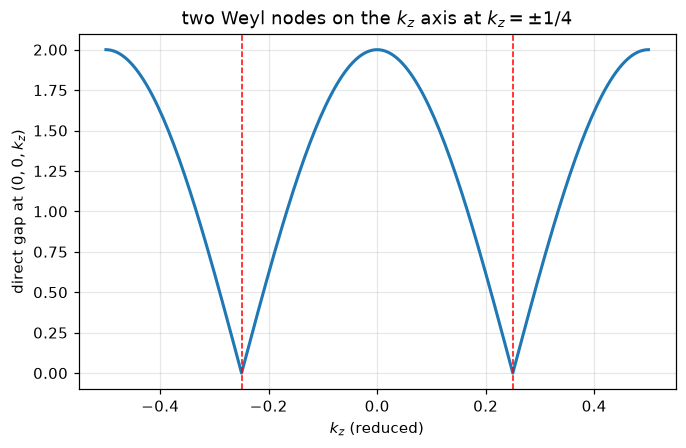

[PASS] nodes are exact band touchings — |E| at nodes = 0.0e+00
[PASS] spectrum is gapped away from the nodes (generic k sample) — min |E| over random k = 0.9166


True

In [3]:
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]])
sz_m = np.diag([1.0, -1.0]).astype(complex)
K0 = np.pi / 2

def weyl_3d():
    lat = Lattice(lat_vecs=np.eye(3), orb_vecs=[[0, 0, 0]], periodic_dirs=[0, 1, 2])
    m = TBModel(lat, spinful=True)
    m.set_onsite([[0, 0, 0, 2 + np.cos(K0)]])
    m.set_hop(-0.5j * sx - 0.5 * sz_m, 0, 0, [1, 0, 0])
    m.set_hop(-0.5j * sy - 0.5 * sz_m, 0, 0, [0, 1, 0])
    m.set_hop(-0.5 * sz_m, 0, 0, [0, 0, 1])
    return m

weyl = weyl_3d()

# the nodes: gap must close exactly at (0,0,±K0) and nowhere else on the kz axis
kz_line = np.linspace(-0.5, 0.5, 201)
k_line = np.stack([np.zeros_like(kz_line), np.zeros_like(kz_line), kz_line], axis=1)
gap_line = np.diff(weyl.solve_ham(k_line), axis=1).ravel()

fig, ax = plt.subplots()
ax.plot(kz_line, gap_line, lw=2)
for kn in (K0 / (2 * np.pi), -K0 / (2 * np.pi)):
    ax.axvline(kn, color="r", ls="--", lw=1)
ax.set_xlabel(r"$k_z$ (reduced)"); ax.set_ylabel("direct gap at $(0,0,k_z)$")
ax.set_title("two Weyl nodes on the $k_z$ axis at $k_z = \\pm 1/4$")
plt.show()
caption("The direct gap along the kz axis: it collapses linearly to zero at "
        "kz = ±¼ and nowhere else — point touchings with conical dispersion in all "
        "three directions. Linear closure in 3D is generic (no fine-tuning): a Weyl "
        "node can only be removed by merging it with a partner of opposite "
        "chirality, which is why the phase is robust without any protecting "
        "symmetry beyond translation.")

gap_at_nodes = np.abs(weyl.solve_ham(np.array([[0, 0, 0.25], [0, 0, -0.25]]))).max()
check("nodes are exact band touchings", gap_at_nodes < 1e-10,
      f"|E| at nodes = {gap_at_nodes:.1e}")
gap_away = np.abs(weyl.solve_ham(rng.random((200, 3)) * 0.9 + 0.05)).min(axis=1).min()
check("spectrum is gapped away from the nodes (generic k sample)", gap_away > 1e-3,
      f"min |E| over random k = {gap_away:.4f}")

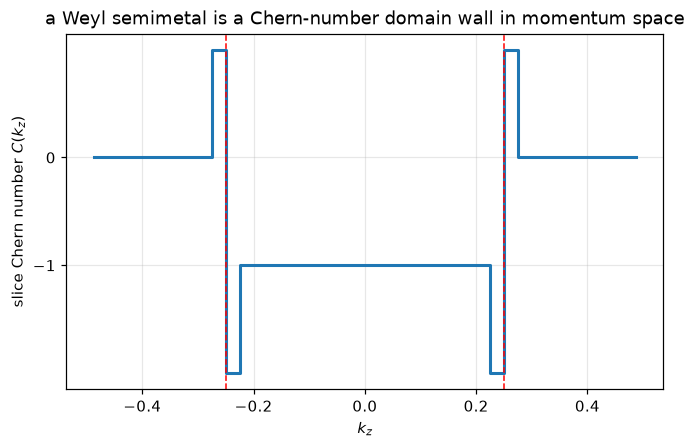

[PASS] C jumps by the chirality χ = ±1 at each node — C between nodes = -1, outside = 0


True

In [4]:
# sliced Chern number C(kz): a 2D model with kz as a symbolic parameter
def weyl_slice():
    lat = Lattice(lat_vecs=np.eye(2), orb_vecs=[[0, 0]], periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    m.set_onsite(lambda kz: [0, 0, 0, 2 + np.cos(K0) - np.cos(2 * np.pi * kz)],
                 ind_i=0)
    m.set_hop(-0.5j * sx - 0.5 * sz_m, 0, 0, [1, 0])
    m.set_hop(-0.5j * sy - 0.5 * sz_m, 0, 0, [0, 1])
    return m

sl = weyl_slice()
# half-step-offset grid: the slice AT a node is gapless and has no Chern number
kz_scan = (np.arange(40) + 0.5) / 40 - 0.5
C_kz = np.array([float(sl.chern_number(plane=(0, 1), nks=(21, 21), occ_idxs=[0], kz=kz))
                 for kz in kz_scan])

fig, ax = plt.subplots()
ax.step(kz_scan, np.round(C_kz), where="mid", lw=2)
for kn in (0.25, -0.25):
    ax.axvline(kn, color="r", ls="--", lw=1)
ax.set_xlabel(r"$k_z$"); ax.set_ylabel(r"slice Chern number $C(k_z)$")
ax.set_yticks([-1, 0])
ax.set_title("a Weyl semimetal is a Chern-number domain wall in momentum space")
plt.show()
caption("The sliced Chern number C(kz), each point computed from a 2D model in "
        "which kz enters as a symbolic parameter: quantized plateaus with unit "
        "jumps exactly at the node positions. The jump measures the chirality of "
        "the node the slice crossed — Weyl nodes are literally the points where "
        "Chern numbers are created and destroyed.")

C_in = np.round(C_kz[np.abs(kz_scan) < 0.2])
C_out = np.round(C_kz[np.abs(kz_scan) > 0.3])
check("C jumps by the chirality χ = ±1 at each node",
      np.all(C_in == C_in[0]) and np.all(C_out == 0) and abs(C_in[0]) == 1,
      f"C between nodes = {C_in[0]:+.0f}, outside = 0")

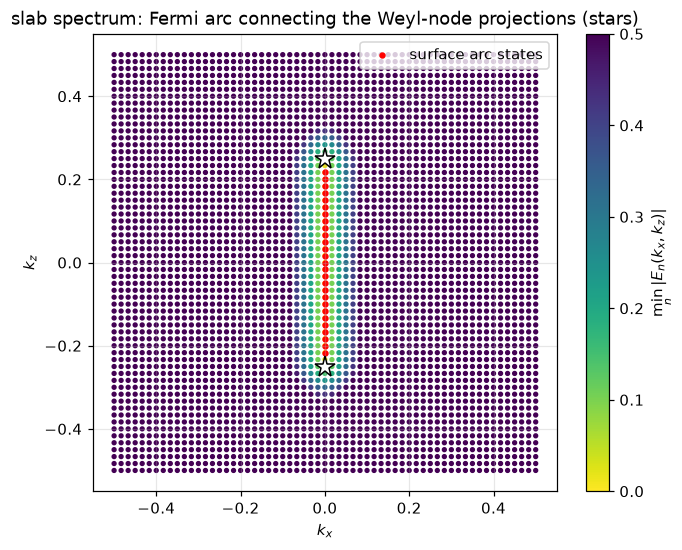

[PASS] Fermi arc spans the region between the node projections — 27 arc points, kz range [-0.22, 0.22]


True

In [5]:
# Fermi arcs: slab finite along y, momentum space (kx, kz)
NSLAB = 24
slab = weyl_3d().cut_piece(NSLAB, 1, glue_edges=False)   # periodic dirs: x and z

nkx, nkz = 61, 61
kxs = np.linspace(-0.5, 0.5, nkx)
kzs = np.linspace(-0.5, 0.5, nkz)
KXg, KZg = np.meshgrid(kxs, kzs, indexing="ij")
k_flat = np.stack([KXg.ravel(), KZg.ravel()], axis=1)

ev, vec = slab.solve_ham(k_flat, return_eigvecs=True)
i_min = np.argmin(np.abs(ev), axis=1)                    # state closest to E=0
E_min = np.take_along_axis(ev, i_min[:, None], 1).ravel()

# surface weight of that state: probability in the outermost 3 cells
y_pos = np.repeat(slab.orb_vecs[:, 1], 2)                # spinful doubling
surf_mask = (y_pos < 3) | (y_pos > NSLAB - 1 - 3 + 1)
psi_min = np.take_along_axis(vec, i_min[:, None, None], 1)[:, 0, :]
w_surf = (np.abs(psi_min) ** 2 * surf_mask).sum(axis=1)

arc = (np.abs(E_min) < 0.05) & (w_surf > 0.6)

fig, ax = plt.subplots(figsize=(6.8, 5.4))
sc = ax.scatter(KXg.ravel(), KZg.ravel(), c=np.abs(E_min).clip(0, 0.5), s=6,
                cmap="viridis_r")
ax.scatter(KXg.ravel()[arc], KZg.ravel()[arc], s=10, c="r", label="surface arc states")
ax.plot([0, 0], [0.25, -0.25], "w*", ms=14, mec="k")
fig.colorbar(sc, label=r"$\min_n |E_n(k_x,k_z)|$")
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_z$")
ax.legend(loc="upper right")
ax.set_title("slab spectrum: Fermi arc connecting the Weyl-node projections (stars)")
plt.show()
caption("Surface physics of the slab: the minimum |E(kx, kz)| over the slab bands "
        "(background) with surface-localized zero-energy states marked in red. "
        "They trace an open ARC connecting the projections of the two nodes — "
        "impossible for any isolated 2D metal, whose Fermi lines must close. The "
        "arc is the collection of chiral edge modes of all the C = −1 slices "
        "between the nodes, seen end-on; its partner lives on the opposite surface.")

# the arc exists between the nodes and not outside
kz_arc = KZg.ravel()[arc]
check("Fermi arc spans the region between the node projections",
      len(kz_arc) > 0 and kz_arc.max() < 0.27 and kz_arc.min() > -0.27
      and (np.abs(kz_arc) < 0.2).sum() > 5,
      f"{arc.sum()} arc points, kz range [{kz_arc.min():.2f}, {kz_arc.max():.2f}]")

<a id="sec-20"></a>

## 20. The Fu–Kane–Mele model and the axion angle $\theta$

The 3D generalization of the quantum spin Hall effect: Fu–Kane–Mele (2007) put spin–orbit-coupled
electrons on the **diamond lattice** and found the first 3D strong topological insulator. Its
magnetoelectric response is captured by the **axion angle**
$$
\theta = \frac{1}{4\pi}\int_{BZ} d^3k\; \epsilon^{ijk}\,
\mathrm{Tr}\Bigl[A_i \partial_j A_k - \tfrac{2i}{3} A_i A_j A_k\Bigr] ,
$$
the Chern–Simons invariant of the occupied bands. Time-reversal (or inversion) pins
$\theta \in \{0, \pi\}$: $\theta = \pi$ *is* the strong TI. Because $\theta$ is only defined modulo
$2\pi$, PythTB 2.0's `axion_angle` tracks it along an *adiabatic sweep*: we add a staggered Zeeman
field of strength $\sin\beta$ and a bond modulation $\cos\beta$ (following the PythTB axion
tutorial), so that $\beta: 0 \to 2\pi$ interpolates trivial → TI → trivial while breaking TRS in
between. Along the cycle $\theta$ advances by $2\pi C_2$, with $C_2$ the **second Chern number** of
the 4D $(\mathbf k, \beta)$ space — the same relation that makes the Thouless pump a Chern number
one dimension up. Θ-odd physics in its cleanest numerical form.

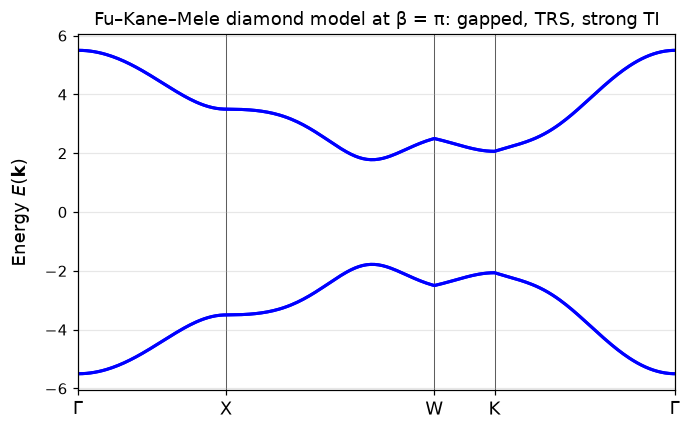

In [6]:
# FKM diamond model + staggered (111) Zeeman of strength m sin(beta), bond
# modulation m cos(beta)  (adapted from the PythTB 2.0 axion tutorial)
t_fkm, soc, m_ax = 1.0, 0.25, 0.5
lat_dia = Lattice([[0, 1, 1], [1, 0, 1], [1, 1, 0]],
                  [[0, 0, 0], [0.25, 0.25, 0.25]], periodic_dirs=...)
fkm = TBModel(lat_dia, spinful=True)
fkm.set_onsite(lambda beta: [0,  m_ax*np.sin(beta),  m_ax*np.sin(beta),  m_ax*np.sin(beta)], ind_i=0)
fkm.set_onsite(lambda beta: [0, -m_ax*np.sin(beta), -m_ax*np.sin(beta), -m_ax*np.sin(beta)], ind_i=1)
for lvec in ([-1, 0, 0], [0, -1, 0], [0, 0, -1]):
    fkm.set_hop(t_fkm, 0, 1, lvec)
fkm.set_hop(lambda beta: 3 * t_fkm + m_ax * np.cos(beta), 0, 1, [0, 0, 0], mode="set")
lvec_list = ([1, 0, 0], [0, 1, 0], [0, 0, 1], [-1, 1, 0], [0, -1, 1], [1, 0, -1])
dir_list = ([0, 1, -1], [-1, 0, 1], [1, -1, 0], [1, 1, 0], [0, 1, 1], [1, 0, 1])
for j in range(6):
    spin = np.array([0.0] + dir_list[j])
    fkm.set_hop(1j * soc * spin, 0, 0, lvec_list[j])
    fkm.set_hop(-1j * soc * spin, 1, 1, lvec_list[j])

# bulk bands at the TRS point beta = pi (this is the strong-TI configuration)
fkm_pi = fkm.with_parameters(beta=np.pi)
DIA_NODES = [[0, 0, 0], [0.5, 0, 0], [0.5, 0.25, 0.75], [0.375, 0.375, 0.75], [0, 0, 0]]
DIA_LABELS = [r"$\Gamma$", "X", "W", "K", r"$\Gamma$"]
fig, ax = fkm_pi.plot_bands(DIA_NODES, k_node_labels=DIA_LABELS, nk=301)
ax.set_title("Fu–Kane–Mele diamond model at β = π: gapped, TRS, strong TI")
plt.show()
caption("Bulk bands of the Fu–Kane–Mele model on the diamond lattice at the "
        "time-reversal-symmetric point of the sweep (β = π), where the (111) bond "
        "strengthened by the modulation makes the system a strong topological "
        "insulator. Every band is doubly degenerate (inversion × time reversal); "
        "the topology hides in the wavefunctions, not in this spectrum — it takes "
        "the axion angle to see it.")

axion sweep on a 24^3 x 25 grid: 10.3 s


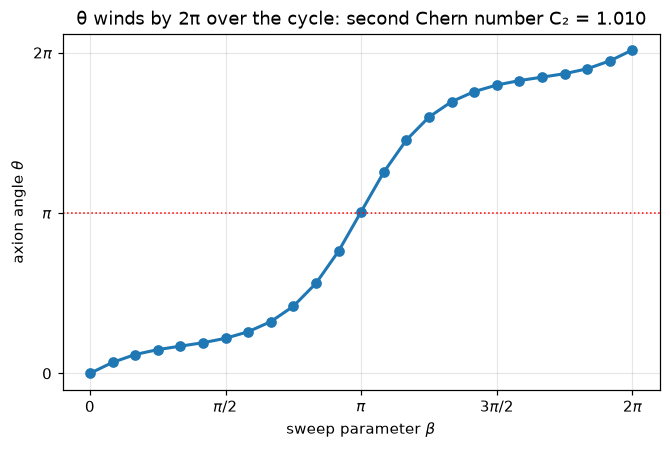

[PASS] second Chern number of the (k,β) cycle is 1 — C2 = 1.0095
[PASS] θ = π at the TRS point β = π (strong TI) — θ(π) = 3.1715
[PASS] θ = 0 at β = 0 (trivial reference)


True

In [7]:
# theta(beta) over the full cycle + second Chern number
n_beta = 25
betas = np.linspace(0, 2 * np.pi, n_beta, endpoint=True)
t0 = time.time()
b_out, theta, c2 = fkm.axion_angle(nks=(24, 24, 24), param_periods={"beta": 2 * np.pi},
                                   return_second_chern=True, diff_scheme="central",
                                   diff_order=6, beta=betas)
theta = np.asarray(theta)
print(f"axion sweep on a 24^3 x {n_beta} grid: {time.time()-t0:.1f} s")

fig, ax = plt.subplots()
ax.plot(betas, theta, "o-", lw=2)
ax.axhline(np.pi, color="r", ls=":", lw=1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
              ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax.set_yticks([0, np.pi, 2*np.pi], ["0", r"$\pi$", r"$2\pi$"])
ax.set_xlabel(r"sweep parameter $\beta$")
ax.set_ylabel(r"axion angle $\theta$")
ax.set_title(f"θ winds by 2π over the cycle: second Chern number C₂ = {c2:.3f}")
plt.show()
caption("The axion angle θ tracked along the adiabatic cycle β: it starts at 0 "
        "(trivial), passes exactly through π at the TRS point β = π — the "
        "quantized magnetoelectric response of a strong TI — and returns having "
        "wound by 2π. The total winding is the second Chern number C₂ = 1 of the "
        "4D (k, β) space: the same mathematics as the Thouless pump, two "
        "dimensions higher. θ-odd physics (surface half-integer Hall response, "
        "image magnetic monopoles) lives on the π plateau.")

check("second Chern number of the (k,β) cycle is 1", abs(c2 - 1) < 0.05,
      f"C2 = {c2:.4f}")
check("θ = π at the TRS point β = π (strong TI)",
      abs(theta[n_beta // 2] - np.pi) < 0.1,
      f"θ(π) = {theta[n_beta // 2]:.4f}")
check("θ = 0 at β = 0 (trivial reference)", abs(theta[0]) < 1e-6)

<a id="exercises-II"></a>

## Exercises for Part II

Worked solutions are in [`PythTB_Exercises_I-II.ipynb`](PythTB_Exercises_I-II.ipynb) (this folder).

**II.1 — Competing masses.** In the Haldane model both $\Delta$ (Semenoff mass) and
$t_2\sin\phi$ (Haldane mass) gap the Dirac points, but with different relative signs at $K$ and
$K'$. Compute the gaps at $K$ and $K'$ separately along a path in $(\Delta, \phi)$ crossing the
phase boundary and show that the transition happens through a gap closing at *one* Dirac point
only.

**II.2 — Kane–Mele phase map.** Automate the WCC-crossing count of §15 into a function
`z2(delta, soc)` and map the $\mathbb{Z}_2$ phase diagram over the $(\Delta, \lambda_{SO})$ plane.
Compare with the analytic boundary $\Delta = 3\sqrt3\,\lambda_{SO}$.

**II.3 — From QSH to QAH.** Add an exchange field $M_z s_z$ to the topological BHZ model. Show
that increasing $M_z$ drives it through a phase with Chern number $C = \pm1$ (a quantum anomalous
Hall phase) before reaching the trivial phase, computing $C$ with `chern_number` at each step.

**II.4 — Corner-charge pump.** Drive the BBH model around the cycle
$\gamma(\lambda) = 1 + 0.8\cos 2\pi\lambda$, $\delta_{onsite}(\lambda) = 0.8\sin 2\pi\lambda$
(add the onsite term with alternating signs on the four orbitals). Track the four corner-state
energies over the cycle and show they traverse the gap — the higher-order analogue of the
Rice–Mele pump.

**II.5 — Kitaev invariant.** For the Kitaev chain, compute the Berry phase of the lower BdG band
around the BZ for $\mu$ from 0 to 3t and show it jumps by $\pi$ at $\mu = 2t$. Explain carefully
*why* this works even though the "occupied band" of a BdG Hamiltonian is not a physical filling —
and what PythTB cannot tell you about the class-D invariant.

**II.6 — Annihilating Weyl nodes.** Add $b\,\sigma_z$ to the Weyl model of §19 and track the node
positions as $b$ varies. Find the critical couplings at which the nodes meet and annihilate — at
the BZ boundary for $b < 0$, at $\Gamma$ for $b > 0$ — and compute the slice Chern numbers beyond
each: the two annihilation channels leave *different* insulators behind. Which one, and why?

In [8]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 6 — checks passed : {_CHECKS['pass']}")
print(f"chapter 6 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 6 — checks passed : 7
chapter 6 — checks failed : 0
wall time                 : 14 s
Every quantitative claim in this notebook was verified in this run.
